In [377]:
# Import modules

from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Enable interactive plot
%matplotlib notebook
%matplotlib notebook

import subprocess
import sys

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher

global particle_number
particle_number=0

from math import floor

import random

particles = 20
iterations = 50
nb_test_0 = 3
nb_test_2 = 7

indexes_0 = []
indexes_2 = []

taille = len(push_data)-1
for i in range(nb_test_0):
    indexes_0.append(int((i+1)*(taille/(nb_test_0+1))))

taille = len(push_data2)
for i in range(nb_test_2):
    indexes_2.append(int((i+1)*(taille/(nb_test_2+1))))

print(indexes_0)  
print(indexes_2)    
    

[16, 32, 48]
[23, 46, 69, 92, 115, 138, 161]


## Load the goal data

In [372]:
push_data = pd.read_csv('PushData.csv',sep=";")[['Pseudo','PushName','MaxForce', 'PerturbationDuration','Final_CoM_y','angle','StepIndex','Impulse']]
push_data = push_data.loc[push_data['angle']==90]
push_data2 = push_data.loc[push_data['StepIndex']==2]
push_data2=push_data2[['Pseudo','PushName','MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse']]
push_data = push_data.loc[push_data['StepIndex']==0]
push_data=push_data[['Pseudo','PushName','MaxForce', 'PerturbationDuration','Final_CoM_y','Impulse']]

push_data = push_data.sort_values(by=['Impulse'])
push_data2 = push_data2.sort_values(by=['Impulse'])


print(len(push_data))
print(len(push_data2))


push_data.head()
#push_data2.head()

result=[20,50,0.1,1,1.5,0.3]

66
185


## Fonction evaluant la stabilité du CoM en fonction des poids kd,kp

In [226]:
def weight_impact_function(param,force,time,i):
   
    #kds = kd1,kd2,kd3,kd4,kd5,kd6,kd7,kd8,kd9,kd10,kd11,kd12,kd13,kd14,kd15,kd16,kd17,kd18
    #kps = kp1,kp2,kp3,kp4,kp5,kp6,kp7,kp8,kp9,kp10,kp11,kp12,kp13,kp14,kp15,kp16,kp17,kp18
    
    
    
    
    
    f = open("gains"+str(i)+".txt", "w")
    f.write(('\n'.join(str(param[i]) for i in range(6))).replace("[","").replace("]",""))
    f.write("\n" + str(force) + " " + str(time) +"\n")
    f.close()

    #subprocess.check_call(['../../bin/App_BulletExampleBrowser_vs2010_x64_debug.exe'])
    
    donnee_1 = pd.read_csv('output'+str(i)+'.txt', sep=" ")
    return donnee_1


def all_particles(input_param):
    result =[0] * particles
    
    
    for i in range(particles):
        print(input_param[i][0])
    for j in range(nb_test_0):
        current_test = push_data.iloc[indexes_0[j]].to_numpy()
        print(current_test)
        #load data trajectory
        ground_1 = pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/' + str(current_test[0]) + 'NA/Mocap/'+str(current_test[1])+'/CSV_export/COM.csv', sep=",",header=None).transpose()
        list_program = []
        for i in range(particles):
            #Get trajectory
            temp = weight_impact_function(input_param[i],current_test[2],current_test[3],i)
        
            if(i%2 == 0):
                list_program.append('../../bin/App_BulletExampleBrowser_vs2010_x64_release0'+str(i)+'.exe')
            else:
                list_program.append('../../bin/App_BulletExampleBrowser_vs2010_x64_release0'+str(i)+'.exe')

        processes = [subprocess.Popen(program) for program in list_program]
        # wait
        
        for process in processes:
            process.wait()
        
        
        for i in range(particles):  
            temp=pd.read_csv('output'+str(i)+'.txt', sep=" ")
            
            #Add error 
            result[i] = result[i] + trajError(ground_1,temp)
            
    for j in range(nb_test_2):
        current_test = push_data2.iloc[indexes_2[j]].to_numpy()
        print(current_test)
        #load data trajectory
        ground_1 = pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/' + str(current_test[0]) + 'NA/Mocap/'+str(current_test[1])+'/CSV_export/COM.csv', sep=",",header=None).transpose()
        list_program = []
        for i in range(particles):
            #Get trajectory
            temp = weight_impact_function(input_param[i],current_test[2],current_test[3],i)
        
            if(i%2 == 0):
                list_program.append('../../bin/App_BulletExampleBrowser_vs2010_x64_release0'+str(i)+'.exe')
            else:
                list_program.append('../../bin/App_BulletExampleBrowser_vs2010_x64_release0'+str(i)+'.exe')

        processes = [subprocess.Popen(program) for program in list_program]
        # wait
        for process in processes:
            process.wait()
        
        
        for i in range(particles):  
            temp=pd.read_csv('output'+str(i)+'.txt', sep=" ")
            #Add error 
            result[i] = result[i] + trajError(ground_1,temp)

         
    print("Resultat : " + str(result))
    result = result 
    return result
        
        

## Optimiser

2023-03-29 10:44:07,550 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.4, 'c2': 0.4, 'w': 0.9, 'initial_velocity': 'random', 'max_velocity_rate': 10000000, 'adaptive': True}


[20, 50, 0.1, 1, 1.5, 0.3]


pyswarms.single.global_best:   0%|                                                                                |0/50

60.54952150008124
44.09297463623524
56.001847521368354
43.16309861054091
38.3377921413678
64.26997524717504
45.0238977819059
65.72995919074977
21.569193588463357
48.26690549423113
50.896885941392696
52.28026320134367
55.82385575445034
24.15773320610468
44.40271954838004
67.6746648523436
65.66466729773354
22.822718567767414
50.4802913399288
36.78631230615554
['CHD1189A' 'PL90_2' 47.56833218138414 0.72 -0.0190774359006173
 15.0045157469518]
0


<IPython.core.display.Javascript object>


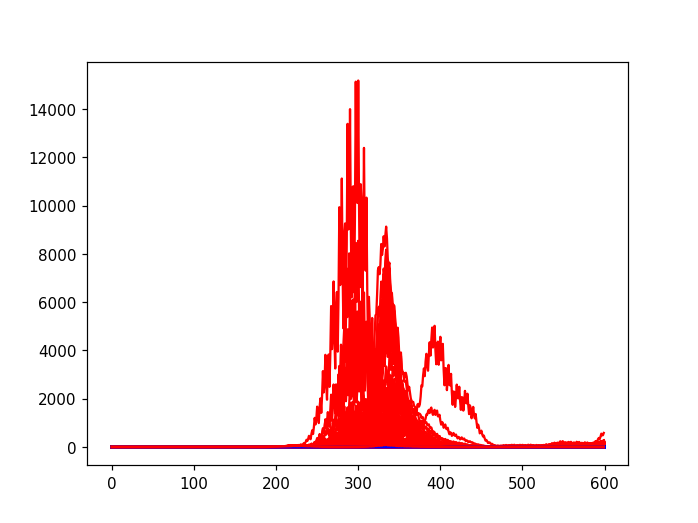

Colonne 1 3.799998224574418

0
Colonne 1 5.414213141142188

0
Colonne 1 4.459403109279577

0
Colonne 1 4.7493135228963785

0
Colonne 1 5.6916581232210515

0
Colonne 1 4.233957793010649

0
Colonne 1 4.718956333031523

0
Colonne 1 4.260277299452074

0
Colonne 1 4.895121355793013

0
Colonne 1 4.1224163790239325

0
Colonne 1 4.134342584459798

0
Colonne 1 4.918874482207738

0
Colonne 1 4.983193333029937

0
Colonne 1 5.0984841330231685

0
Colonne 1 5.208250948928097

0
Colonne 1 4.638586657097833

0
Colonne 1 4.28069064138042

0
Colonne 1 6.888560602357718

0
Colonne 1 5.011526652105432

0
Colonne 1 4.061542516800371

['DEL0696A' 'PM90_1' 56.33898440753045 0.585 0.165075082674012
 17.60642381974615]
0
Colonne 1 3.316221882140613

0
Colonne 1 2.095516088397297

0
Colonne 1 2.7931055386575454

0
Colonne 1 2.2450288369419575

0
Colonne 1 2.073942006841858

0
Colonne 1 2.707504591700998

0
Colonne 1 2.3980585300436066

0
Colonne 1 2.634187850309626

0
Colonne 1 2.1008973033243548

0
Colonne 1 2

pyswarms.single.global_best:   2%|█▎                                                              |1/50, best_cost=53.7

549
Colonne 1 14.696443551457579

Resultat : [250.3616518357572, 60.35408247407183, 74.87289654333794, 57.12722689041996, 54.56094821987993, 79.51327148648693, 53.68383490537574, 108.17053136451611, 63.39871588043871, 69.51760457031578, 75.50662638454386, 76.41791507869235, 53.984331600234796, 129.718438175814, 68.84073454045004, 55.61266933369535, 63.60699855467375, 568.6861426901241, 57.64357900642442, 81.72346586695635]
58.62832537684019
44.45877276999041
55.55279026362531
43.626884115502605
38.66048610802545
64.74135974227522
45.187057346420225
65.24042923441866
22.738919697702972
48.54987393490804
49.2102928537824
52.44629217938561
53.549800510709744
28.98558815063052
45.03952112634476
65.78054597505314
59.998291767059065
26.906772149048077
48.77394121895598
39.679362260648965
['CHD1189A' 'PL90_2' 47.56833218138414 0.72 -0.0190774359006173
 15.0045157469518]
0
Colonne 1 4.1810153693331245

0
Colonne 1 4.295501233619978

0
Colonne 1 3.084224050091441

0
Colonne 1 5.768442800817561


pyswarms.single.global_best:   4%|██▌                                                             |2/50, best_cost=50.5

549
Colonne 1 11.65466254527079

549
Colonne 1 8.311810395236547

Resultat : [117.25017817874644, 432.6195662260005, 58.86369044637767, 77.57985678641056, 143.45295740104018, 76.13366707241232, 50.500224029277916, 160.9768248791607, 103.37032056762311, 61.78273020509047, 68.50856971413282, 95.81934633638659, 62.99133064182436, 446.14947493948426, 71.5622355375392, 71.0757607986294, 209.09067402804425, 51.84324446258522, 66.64227803843522, 68.18895232019837]
56.13797297833083
44.86813014587626
51.25177796301814
43.97933231014836
40.30987590942692
65.07371891815212
45.33390095448311
61.60549929317706
25.36666850812282
48.25044134278611
46.720040036270476
50.05513385753471
48.635120755334725
33.303322616258704
45.430807181573144
57.46386543801994
53.23975971019574
35.14410621098618
46.95774794149612
43.053271879458045
['CHD1189A' 'PL90_2' 47.56833218138414 0.72 -0.0190774359006173
 15.0045157469518]
0
Colonne 1 4.961889055314024

0
Colonne 1 4.259553579724526

0
Colonne 1 3.98061974893710

...

549
Colonne 1 9.224308232041974

Resultat : [48.68889776480338, 64.55574878231421, 78.2465395245159, 61.08213276669842, 366.09485321999216, 61.505131173725125, 59.148341735039686, 48.22748579889504, 49.72558667694883, 76.20488683606037, 48.926781622117474, 65.54603718639225, 80.51846575403934, 54.79891624342903, 48.54864130861215, 48.85939579878277, 62.471660767299475, 97.77586343195864, 51.65605517581448, 49.61167344298272]
43.148010401082495
43.672534080748726
43.707246714528914
45.56959712759217
42.375131692996405
43.4399433292087
43.78005439918845
42.23047290764235
42.06644510764418
44.261322448306224
43.23476883262659
42.94515863937053
43.46037659137841
42.9352771194887
43.60235764804255
42.697832288947495
20.974420286174848
42.84158782391183
43.05307643748747
44.01360743263016
['CHD1189A' 'PL90_2' 47.56833218138414 0.72 -0.0190774359006173
 15.0045157469518]
0
Colonne 1 4.682699138553144

0
Colonne 1 4.561606034904123

0
Colonne 1 4.64548449227933

0
Colonne 1 4.37550062052173

0

pyswarms.single.global_best:  98%|█████████████████████████████████████████████████████████████▋ |49/50, best_cost=47.5

Colonne 1 9.019674068761462

Resultat : [49.25064693781065, 64.22817325136651, 81.05262486237353, 50.62587124809092, 57.37128908237001, 76.59319506228437, 60.492398311518954, 140.19290617867603, 49.048480969089034, 151.24481181985036, 62.45352627997839, 58.42998881514676, 71.41739769013975, 49.76713084605582, 51.071064204509646, 51.448302856985364, 107.50807121772613, 56.0014297999263, 61.626257079761025, 64.45695265872254]
43.18858268186878
43.153632041327846
43.685840621025996
45.75927141475941
43.153689731913
43.5449638151664
43.88312196691156
42.37105225248371
42.08446368221777
43.672013998039276
43.25124768397342
43.122674284326486
43.56466150760994
42.87085408876584
43.382190291595144
42.88668072728937
42.092698504148956
42.597454754910125
42.99401193617168
44.27605440492232
['CHD1189A' 'PL90_2' 47.56833218138414 0.72 -0.0190774359006173
 15.0045157469518]
0
Colonne 1 5.297076331456596

0
Colonne 1 4.692834591626688

0
Colonne 1 4.679181771218931

0
Colonne 1 4.847830305195071

0

pyswarms.single.global_best: 100%|███████████████████████████████████████████████████████████████|50/50, best_cost=46.7
2023-03-29 18:02:06,062 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 46.682892438646185, best pos: [42.371 42.054  0.206  1.327  1.796  0.296]


Colonne 1 29.17245940082202

549
Colonne 1 10.711831857566013

549
Colonne 1 9.247925854692133

549
Colonne 1 9.453431115368108

Resultat : [67.3974834799443, 49.41249598794131, 72.22143597293184, 115.74646217703716, 53.809459571670196, 50.723261062041786, 51.137281631792554, 46.682892438646185, 47.899470300538184, 81.93171071540242, 49.21205053939472, 54.61423707442678, 48.07066379464112, 57.376643138774895, 62.1357531593202, 52.34675999960615, 86.85080389908049, 52.6782803677096, 56.860931074526015, 64.17629159125657]


In [375]:
dataa=[]

kwargs = { "kd2":0, "kd3":-900, "kd4":-900, "kd5":-20, "kd6":-20, "kd7":-900, "kd8":-900, "kd9":-20, "kd10":-20, "kd11":-20, "kd12":-20, "kd13":-1200, "kd14":-1200, "kd15":-20, "kd16":-10, "kd17":-20, "kd18":-10,"kp2":0,"kp3":-10, "kp4":-10, "kp5":-1, "kp6":-1, "kp7":-10, "kp8":-10, "kp9":-1.5, "kp10":-1.5, "kp11":-1.5, "kp12":-1.5, "kp13":-20, "kp14":-20, "kp15":-1, "kp16":0, "kp17":-1, "kp18":0,"force":36,"time":0.55}
kwargs={}
max_bound = [70,90,0.25,1.5,2.5,0.4]
min_bound = [20,30,0,0.5,1,0]
print(result)
bounds = (min_bound, max_bound)
options = {'c1': 0.4, 'c2': 0.4, 'w':0.9, 'initial_velocity':"random",'max_velocity_rate':10000000,'adaptive':True}
np_vers = np.array([result]*particles).astype(np.float32)
optimizer = ps.single.GlobalBestPSO(n_particles=particles, dimensions=6, options=options, bounds=bounds)
cost, pos = optimizer.optimize(all_particles, **kwargs,iters=iterations)

memoire=pos
f = open("resultatTraj.txt", "w")
for i in range(len(memoire)):
    f.write((str(memoire[i]) + " "))
    f.write("\n")
f.close()

In [368]:
print(pos)

[53.198 92.19   0.359  0.86   1.941  0.257]


## Visualiser l'optimisation

In [349]:
from pylab import *
from scipy.signal import savgol_filter

def trajError(ground,subject):
    
    #print(ground)
    #print(subject)
    
    res=0
    
    for col in {1}:
    
        try:
            pic1,_,gpr = findStart(ground[: len(ground) - 150],col)
        except TypeError:
            pic1,_,gpr = 0,_,2

        pic2=200      
        
        if(pic1>=pic2):
            pic1 = pic1-pic2
            pic2=0
        else :
            pic2 = pic2-pic1
            pic1=0
        
        end = min(len(subject)-pic2,len(ground)-pic1)
        

        y=[]
        g2=[]
        for i in range(0,end):
            y.append(subject['Z'].iloc[i+pic2])
            g2.append(ground.iloc[:, col].iloc[i+pic1])
        
        FilteredY = savgol_filter(subject['Z'], 55, 5)
        FDerivY = TemporalDeriv(FilteredY)

        FilteredG = savgol_filter(ground.iloc[:,1], 55, 5)
        FDeriG = TemporalDeriv(FilteredG)
    
        maxY = argmax(FDerivY)
        maxG = argmax(FDeriG)
        if(maxG > (len(FDeriG)-301)):
            maxG= len(FDeriG)-301
        if(maxG > (len(FDerivY)-301)):
            maxG= len(FDerivY)-301
        if(maxG < 301):
            maxG= 301
        if(maxY < 301 ):
            maxY= 301   
            
        y=[]
        for i in range(maxY-300,maxY+300):
            y.append(FDerivY[i])
        g2=[]
        for i in range(maxG-300,maxG+300):
            g2.append(FDeriG[i])  
            
            
            
            
        x=[]
        for i in range(0,600):
            x.append(i)
        plt.plot(x,y, 'r', linestyle='-')
            
        x=[]
        for i in range(0,600):
            x.append(i)
        plt.plot(x,g2, 'b', linestyle='-')
            
        #diff = abs(1-(0.2+(y))/(0.2+(g2)))
        diff = pow(2,10*abs(np.array(y)-np.array(g2)))
            
        res+= sum(diff)/len(diff)
        
        x=[]
        for i in range(0,600):
            x.append(i)
        plt.plot(x,diff, 'r', linestyle='-')
        
        
        print('Colonne ' + str(col) + ' '+ str(sum(diff)/len(diff)) + '\n')
        
        
        
    return res
    

def findStart(ground_1,index):
    x = [0]*(len(ground_1)-1)
    y = [0]*(len(ground_1)-1)
    
    for i in range(0,len(ground_1)-1):
        x[i] = i
        y[i] = 2000*(ground_1.iloc[:,index].iloc[i+1]-ground_1.iloc[:,index].iloc[i])
    
    return(ComputePerturbationDuration(y))

def ComputePerturbationDuration(ForceData,Treshold=0.25):
    """ Return the index of Time at wich the push Start and End"""

    StartIndex = 0
    EndIndex = len(ForceData)-1

    MaxForce = max(ForceData)
    MaxIndex = argmax(ForceData)
    
    ## Filtered Normal Deriv of the force 
    FilteredForce = savgol_filter(ForceData, 55, 5)
    FDeriv = TemporalDeriv(FilteredForce)/max(abs(TemporalDeriv(FilteredForce)))
    
    
      
       
            
    ## Find the first Zero before rising edge
    i = argmax(FDeriv)# rising edge index
    while StartIndex == 0 and i>0:
        if FDeriv[i]<=0.1 and ForceData[i]/max(ForceData)<Treshold:  
            StartIndex = i
        i -= 1
        
    ## Find the first Zero after falling edge
    i = argmin(FDeriv)# rising edge index
    while EndIndex == len(ForceData)-1 and i<len(ForceData)-1:
        if FDeriv[i]>=0.1 and ForceData[i]/max(ForceData)<Treshold:  
            EndIndex = i
        i += 1    
    
    ## Treatment of the no force trial (when the sensor failed)
    if max(ForceData-ForceData[StartIndex])<5:
        StartIndex, EndIndex = 0,1
    
    print(StartIndex)
    
    return StartIndex, EndIndex , ForceData

def TemporalDeriv(X, dt = 1/200):
    """ 2nd Order time derivative of X. 
        Where X is an array of n dimention*(Nb of frame).
        dt is the duration in seconds of the time step. """
    if len(shape(X))>1: # if X have more than one dimention
        DerivX = zeros(X.shape)
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[:,0] = (4*X[:,1] - 3*X[:,0] - X[:,2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[:,-1] = (-4*X[:,-2] + 3*X[:,-1] + X[:,-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X[0])-1):
            DerivX[:,i] = (X[:,i+1]-X[:,i-1])/(2*dt)
    else :
        DerivX = zeros(len(X))
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[0] = (4*X[1] - 3*X[0] - X[2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[-1] = (-4*X[-2] + 3*X[-1] + X[-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X)-1):
            DerivX[i] = (X[i+1]-X[i-1])/(2*dt)

    return DerivX

822
822
200
317
1039


<IPython.core.display.Javascript object>


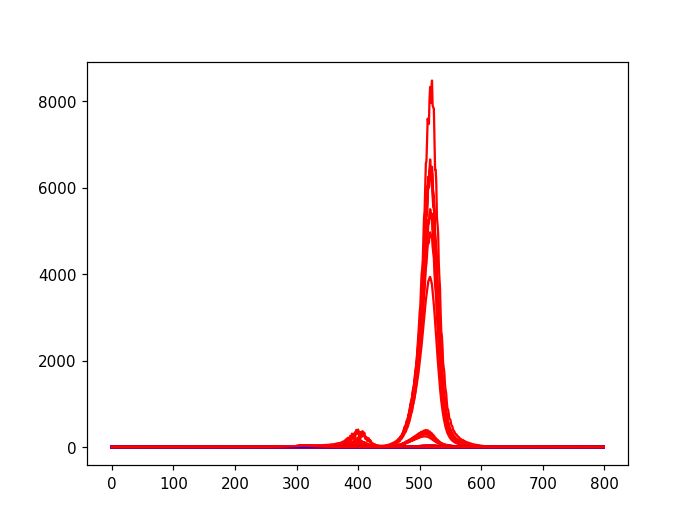

Colonne 1 4.206080104416153



4.206080104416153

In [344]:
ground_1 = pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/GEC0801ANA/Mocap/PH90_1/CSV_export/COM.csv', sep=",",header=None).transpose()
temp=pd.read_csv('output0.txt', sep=" ")
            
trajError(ground_1,temp)



<IPython.core.display.Javascript object>


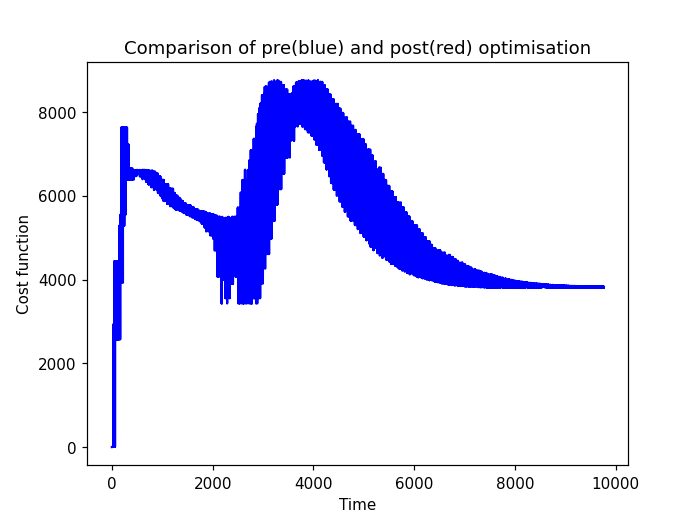

[[20, 50, 0.1, 1, 1.5, 0.3]]
[42.371 42.054  0.206  1.327  1.796  0.296]
[309.3872214394197]
Valeur de base : [309.3872214394197] --->[198.67493064013732] ( -35.78437735217214 % )


In [381]:
np.set_printoptions(suppress=True)
np.set_printoptions(precision=3)
#print(pos)
#print(len(dataa))
x=[]
y=[]
y2=[]

donnee_1 = pd.read_csv('output.txt', sep=" ")

plt.xlabel('Applied impulse')
plt.ylabel('Total displacement')
plt.title('Comparison of simulation and real data (simulation in orange)')
    
def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

case=5

if(case==1):
    
    plt.xlabel('Iteration')
    plt.ylabel('Cost function')
    plt.title('Cost history thoughout optimisation')

    
    #print(optimizer.cost_history)

    for i in range(len(optimizer.cost_history)):
        x.append(i)
        y.append(optimizer.cost_history[i])
    plt.plot(x,y, 'ro', linestyle='-')
else :
    if (case==2):
        #plt.ylim(-0.3,1.3)
        #plt.xlim(-0.1,1.3)
        #plt.xlim(10,60)

        #plt.plot([-0.1, 1000], [0.15, 0.15], 'r-.', lw=2)
        #plt.plot([-0.1, 1000], [-0.15, -0.15], 'r-.', lw=2)
        #plt.plot([-100, -0.1], [1000, -0.1], 'r-', lw=2)

        print(optimizer.cost_history)

        for i in range(len(dataa)):
            x.append(dataa[i][4])
            y.append(dataa[i][3]+abs(dataa[i][2]))
            #y.append(dataa[i][3])
            #y.append(0.95*dataa[i][2]+(dataa[i][3]-0.37))
            y2.append(dataa[i][2])
        plt.plot(x,y, 'ro', linestyle='None')
        plt.plot(x,y2, 'bo', linestyle='None')

        coef = np.polyfit(x,y,1)
        poly1d_fn = np.poly1d(coef) 
        coef_data = np.polyfit(x,y2,1)
        poly1d_fn_data = np.poly1d(coef_data) 
        # poly1d_fn is now a function which takes in x and returns an estimate for y
        plt.plot(x,y,'o', x, poly1d_fn(x), 'r-')

        plt.plot(x,y,'o', x, poly1d_fn_data(x), 'b-')

        #plt.plot([0, 2], [0, 2], 'g-', lw=2)

        #plot_cost_history(cost_history=optimizer.cost_history)
        print(str(np.sum(y)/len(y)))
    else:
        if(case==3):
            cmap = get_cmap(18)

            for j in range(0,1):
                x=[]
                y=[]
                for i in range(len(donnee_1.iloc[:, j])):
                    x.append(i)
                    y.append(donnee_1.iloc[:, j].iloc[i])
                plt.plot(x,y, c=cmap(j), linestyle='-')
                
                print(100*sum(y)/200)
                
            for j in range(1,2):
                x=[]
                y=[]
                for i in range(len(donnee_1.iloc[:, j])):
                    x.append(i)
                    y.append(donnee_1.iloc[:, j].iloc[i])
                plt.plot(x,y, c=cmap(j), linestyle='-')
                
                print(0.01*sum(y)/200)
                
                
if(case==4):
    origin=[[20,50,0.1,1,1.5,0.3]]
    temp = particles
    particles=1
    val_origin = all_particles(origin)
    donnee_ori = pd.read_csv('output0.txt', sep=" ")
    val_result = all_particles([result])
    donnee_res = pd.read_csv('output0.txt', sep=" ")  
    particles=temp
    
if(case==5):
    
    plt.xlabel('Time')
    plt.ylabel('Cost function')
    plt.title('Comparison of pre(blue) and post(red) optimisation')

    print(origin)
    print(result)
    scan=range(1,2)
    
    
    cmap = get_cmap(18)
    

    x=[0]*len(donnee_1.iloc[:, 0])
    y=[0]*len(donnee_1.iloc[:, 0])
    for j in scan:
            for i in range(len(donnee_1.iloc[:, j])):
                x[i] = i
                y[i] += donnee_1.iloc[:, j].iloc[i]
    plt.plot(x,y, 'b', linestyle='-')
    
    

    x=[0]*len(donnee_res.iloc[:, j])
    y=[0]*len(donnee_res.iloc[:, j])
    for j in scan:
            for i in range(len(donnee_res.iloc[:, j])):
                x[i] = i
                y[i] += donnee_res.iloc[:, j].iloc[i]/len(donnee_res.iloc[:, j])
    #plt.plot(x,y, 'r', linestyle='-')

    print(val_origin)
    print("Valeur de base : " + str(val_origin) + " --->" + str(val_result) + " ( -"+ str(100*(val_origin[0]-val_result[0])/val_origin[0]) + " % )")

    
if(case==6):
    x=[0]*20
    y=[0]*20
    print(origin)
    print(result)
    
    for i in range(0,20):
        x[i] = i
        y[i] = (result[i]-0.5*origin[0][i])/(origin[0][i])
    #plt.plot(x,origin[0], 'r', linestyle='-')
    plt.plot(x,y, 'b', linestyle='-')
plt.show()

## Sauvegarde des données

In [376]:
memoire = dataa
result = pos
temp=result
result[np.isnan(result)] = 0
np.set_printoptions(suppress=True)
np.set_printoptions(precision=3)
for i in range(int(len(result)/2)) :
    print(str(result[i])+ " " +str(result[int(i+len(result)/2)]))

val_original = np.array([-500,0,-300, -500, -500, -10, -10, -1000, -50, -50,   -100,0,-10, -20, -20,  -1, -1, -20, -5, 0]).astype(np.float32)
print((result - val_original*0.8)/( val_original*0.4))
print("")
print(val_original*1.2-result)
f = open("resultat.txt", "w")
for i in range(len(memoire)):
    for j in range(len(memoire[0])):
        f.write((str(memoire[i][j]) + " "))
    f.write("\n")
f.close()

42.37105225248371 1.3274185940479835
42.05437170004417 1.7961891104626564
0.2058245166324224 0.29621277854850253


ValueError: operands could not be broadcast together with shapes (6,) (20,) 

In [11]:
donnee_1 = pd.read_csv('output.txt', sep=" ")
donnee_1.head()


,qdot,q,torque,X,Z,vX,vZ,pasEffectue,Unnamed: 8
0,0.0,0.0,0.0,-0.0,-0.005862,-0.0,-0.005862,0,0.0
1,-0.0,0.0,-0.0,-0.0,-0.005862,-0.0,-0.005862,0,0.0
2,-0.0,0.0,-0.0,-0.0,-0.005862,-0.0,-0.005862,0,0.0
3,-0.0,0.0,-0.0,-0.0,-0.005862,-0.0,-0.005862,0,0.0
4,-0.0,0.0,-0.0,0.0,-0.005862,0.0,-0.005862,0,0.0


## Calcul erreur

## Resultat ?

In [365]:
print(optimizer.pos_history[1][2])
result = optimizer.pos_history[1][2]

[-489.115      nan -307.8   -474.099 -496.728  -10.337  -11.807 -978.295
  -52.907  -43.981 -106.011      nan  -10.75   -16.522  -20.065   -1.082
   -1.187  -20.082   -4.452      nan]


In [214]:


print(len(push_data2))
x=[]
y=[]
plt.xlabel('Applied impulse')
plt.ylabel('Total displacement')
plt.title('Comparison of simulation and real data (simulation in orange)')
    
    
#plt.ylim(-0.3,1.3)
#plt.xlim(-0.1,1.3)
plt.xlim(10,60)
 
#plt.plot([-0.1, 1000], [0.15, 0.15], 'r-.', lw=2)
#plt.plot([-0.1, 1000], [-0.15, -0.15], 'r-.', lw=2)
#plt.plot([-100, -0.1], [1000, -0.1], 'r-', lw=2)



for i in range(len(push_data2)):
    x.append(push_data2.iloc[i][3])
    y.append(push_data2.iloc[i][2])
plt.plot(x,y, 'ro', linestyle='None')

coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y
plt.plot(x,y,'o', x, poly1d_fn(x), 'r-')
print(coef)

plt.plot([0, 2], [0, 2], 'g-', lw=2)

#plot_cost_history(cost_history=optimizer.cost_history)
print(str(np.sum(y)/len(y)))
#plt.show()

185
[0.014 0.069]
0.4914289440207285


In [8]:
#import matplotlib.pyplot as plt2
x=[]
y=[]
for i in range(len(push_data2)):
    x.append(push_data2.iloc[i][3])
    y.append(push_data2.iloc[i][2])

coef = np.polyfit(x,y,1)
poly1d_fn_1 = np.poly1d(coef) 

x=[]
y=[]
for i in range(len(push_data)):
    x.append(push_data2.iloc[i][3])
    y.append(push_data2.iloc[i][2])

coef = np.polyfit(x,y,1)
poly1d_fn_2 = np.poly1d(coef) 

def compute_jerk(velocities):
    
    x=[]
    y=[] #vélocités
    y2=[] #acceleration
    y3=[] #jerk
    
    x.append(0)
    y.append(0)
    y2.append(0)
    y3.append(0)
    for i in range(len(donnee_1)):
        x.append(i)
        y.append(velocities[i])
        y2.append((y[i]-y[i-1])*10)
        y3.append((y2[i]-y2[i-1])*10)
    return sum(map(abs, y3))

def compute_vel(velocities):
    
    x=[]
    y=[] #vélocités
    y2=[] #acceleration
    
    x.append(0)
    y.append(0)
    y2.append(0)
    for i in range(len(donnee_1)):
        x.append(i)
        y.append(velocities[i])
        y2.append((y[i]-y[i-1])*10)
    return sum(map(abs, y2))

def analyse(impulse,pasEntree):
    donnee_1 = pd.read_csv('output.txt', sep=" ")
    
    result = 0
    for j in range(2):
        for i in range(len(donnee_1.iloc[:, j])):
               result += donnee_1.iloc[:, j].iloc[i]
                
    result=0
    for j in range(0,1):
        x=[]
        y=[]
        for i in range(len(donnee_1.iloc[:, j])):
            x.append(i)
            y.append(donnee_1.iloc[:, j].iloc[i])
             
        if((100*sum(y)/200)>100):
            result += 1000*sum(y)/200
        else :
            print("CLEAR!\n")
            
    result=0           
    for j in range(1,2):
        x=[]
        y=[]
        for i in range(len(donnee_1.iloc[:, j])):
            x.append(i)
            y.append(donnee_1.iloc[:, j].iloc[i])
                
        result += 0.01*sum(y)/200
              
    return result